In [1]:

import mrcfile 
import numpy as np
import torchvision.datasets
import datetime
import os
import torch
from tqdm import tqdm
from torch.utils.data import DataLoader
# import transformers
import pytorch_lightning as pl
# import supervision as sv
from transformers import DetrConfig, DetrForObjectDetection, DetrImageProcessor, DetrForSegmentation, ConditionalDetrForObjectDetection,ConditionalDetrConfig,ConditionalDetrForSegmentation
import torch
import sys 
sys.path.append("/home/tyfei/cyroem")
import importlib 
import utils
import matplotlib.pyplot as plt
from torchvision.transforms import v2
import modules
import data
importlib.reload(utils)
importlib.reload(modules)
import json
import torch.nn as nn
from functools import partial
import torchmetrics

/home/feity/anaconda3/envs/pytorch/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### play with GCN

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv
from torch_geometric.nn import SAGEConv
import torch.nn as nn

# Load the Cora dataset (node classification task)
dataset = Planetoid(root='./Cora', name='Cora')

# Define the GNN model (Graph Convolutional Network - GCN)
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GCN, self).__init__()
        # self.conv1 = GCNConv(in_channels, hidden_channels)
        # self.conv2 = GCNConv(hidden_channels, hidden_channels)
        # self.conv3 = GCNConv(hidden_channels, out_channels)
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.conv3 = SAGEConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        # First GCN layer
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        # Second GCN layer
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        # Third GCN layer
        x = self.conv3(x, edge_index)
        return F.log_softmax(x, dim=1)

# Initialize the model, optimizer, and loss function
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GCN(dataset.num_node_features, hidden_channels=32, out_channels=dataset.num_classes).to(device)
data = dataset[0].to(device)  # Load the graph data
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)

# Training loop
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)  # Forward pass
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])  # Loss for training nodes
    loss.backward()
    optimizer.step()
    return loss.item()

# Test function
def test():
    model.eval()
    out = model(data.x, data.edge_index)  # Forward pass
    pred = out.argmax(dim=1)  # Predicted labels
    correct = (pred[data.test_mask] == data.y[data.test_mask]).sum()
    acc = int(correct) / int(data.test_mask.sum())
    return acc

# Train the model for 200 epochs
for epoch in range(1, 1201):
    loss = train()
    acc = test()
    print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Test Accuracy: {acc:.4f}')


In [19]:
data.edge_index.shape

torch.Size([2, 10556])

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv

# Load the Cora dataset (node classification task)
dataset = Planetoid(root='/tmp/Cora', name='Cora')

# Define the GNN model (Graph Convolutional Network - GCN)
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        # First GCN layer
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        # Second GCN layer
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

# Initialize the model, optimizer, and loss function
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GCN(dataset.num_node_features, hidden_channels=16, out_channels=dataset.num_classes).to(device)
data = dataset[0].to(device)  # Load the graph data
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

# Training loop
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)  # Forward pass
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])  # Loss for training nodes
    loss.backward()
    optimizer.step()
    return loss.item()

# Test function
def test():
    model.eval()
    out = model(data.x, data.edge_index)  # Forward pass
    pred = out.argmax(dim=1)  # Predicted labels
    correct = (pred[data.test_mask] == data.y[data.test_mask]).sum()
    acc = int(correct) / int(data.test_mask.sum())
    return acc

# Train the model for 200 epochs
for epoch in range(1, 201):
    loss = train()
    acc = test()
    print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Test Accuracy: {acc:.4f}')


In [3]:
path = "/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr_mrc/whole_123_mask1"
with open(os.path.join(path, "config.json"), "r") as f:
    configs = json.load(f)
model = utils.getModel(configs)

Some weights of ConditionalDetrForObjectDetection were not initialized from the model checkpoint at microsoft/conditional-detr-resnet-50 and are newly initialized because the shapes did not match:
- class_labels_classifier.bias: found shape torch.Size([91]) in the checkpoint and torch.Size([4]) in the model instantiated
- class_labels_classifier.weight: found shape torch.Size([91, 256]) in the checkpoint and torch.Size([4, 256]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/home/feity/anaconda3/envs/pytorch/lib/python3.12/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


model at stage  stage 1 + 2 + 3


/home/feity/cryoem/utils.py:818: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  t = torch.load(configs["model"]["load"], map_location="cpu")


incompatible parameters ['model.class_labels_classifier.weight', 'model.class_labels_classifier.bias', 'additional_input_layer.layer1.weight', 'additional_input_layer.layer1.bias', 'additional_input_layer.layer2.weight', 'additional_input_layer.layer2.bias', 'gnn.conv1.lin_l.weight', 'gnn.conv1.lin_l.bias', 'gnn.conv1.lin_r.weight', 'gnn.conv2.lin_l.weight', 'gnn.conv2.lin_l.bias', 'gnn.conv2.lin_r.weight', 'gnn.conv3.lin_l.weight', 'gnn.conv3.lin_l.bias', 'gnn.conv3.lin_r.weight', 'gnn.cls_head.0.weight', 'gnn.cls_head.0.bias', 'gnn.cls_head.2.weight', 'gnn.cls_head.2.bias', 'gnn.box_head.0.weight', 'gnn.box_head.0.bias', 'gnn.box_head.2.weight', 'gnn.box_head.2.bias', 'gnn.edge_head.0.weight', 'gnn.edge_head.0.bias', 'gnn.edge_head.2.weight', 'gnn.edge_head.2.bias', 'gnn.edge_head.4.weight', 'cri.weight', 'mask_head.inc.double_conv.0.weight', 'mask_head.inc.double_conv.1.weight', 'mask_head.inc.double_conv.1.bias', 'mask_head.inc.double_conv.3.weight', 'mask_head.inc.double_conv.4.we

In [ ]:
model = utils.load_model(model, os.path.join(path, "best_model.pth"))

In [239]:
ds = utils.get_stage12_dataset(configs)
dl = ds.train_dataloader()
for i, j in enumerate(dl):
    break

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
using batch size  8
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
using batch size  8
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
using batch size  8
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
using batch size  8
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
using batch size  8
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
using batch size  8
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
using batch size  8
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
using batch size  8
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
using batch size  8
loading annotations into memory...
Done (t=0.01s)
creating index...
index

In [248]:
j[0]["mark"]

['/data/transformer_project/transforemer_model/train_data/training/data/annotations/TS_023.pkl',
 '/data/transformer_project/transforemer_model/train_data/training/data/annotations/TS_023.pkl',
 '/data/transformer_project/transforemer_model/train_data/training/data/annotations/TS_023.pkl',
 '/data/transformer_project/transforemer_model/train_data/training/data/annotations/TS_023.pkl',
 '/data/transformer_project/transforemer_model/train_data/training/data/annotations/TS_023.pkl',
 '/data/transformer_project/transforemer_model/train_data/training/data/annotations/TS_023.pkl',
 '/data/transformer_project/transforemer_model/train_data/training/data/annotations/TS_023.pkl',
 '/data/transformer_project/transforemer_model/train_data/training/data/annotations/TS_023.pkl']

In [246]:
j[0]["labels"][0].keys()

dict_keys(['bboxes', 'class_labels', 'item_id', 'orig_size', 'size', 'image_id', 'boxes', 'area', 'iscrowd', 'pos'])

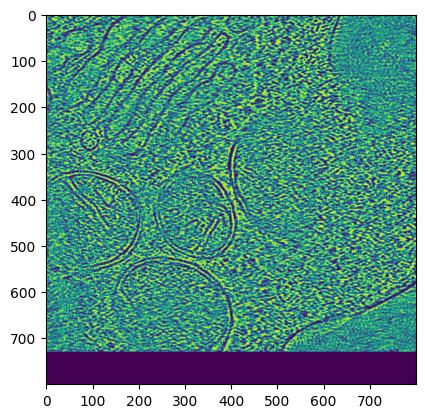

In [230]:
plt.imshow(j[0]["pixel_values"][0][1])

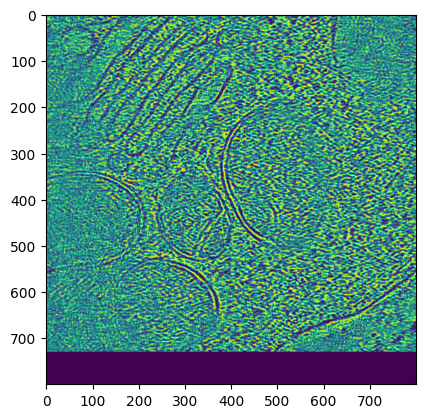

In [232]:
plt.imshow(j[0]["pixel_values"][4][1])

In [215]:
j[0]["pixel_values"].shape

torch.Size([5, 3, 800, 800])

In [193]:
if configs["model"]["stage"] == "stage 1":
    ds = utils.get_stage1_dataset(configs)
elif configs["model"]["stage"] == "stage 2":
    ds = utils.get_stage2_dataset(configs)
elif configs["model"]["stage"] == "stage mask":
    ds = utils.get_stageMask_dataset(configs)

/home/feity/cryoem/utils.py:898: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data_list_train.append(torch.load(i))
/home/feity/cryoem/utils.py:902: FutureWarning: You are 

In [196]:
model = utils.getModel(configs)

Some weights of the model checkpoint at SenseTime/deformable-detr were not used when initializing DeformableDetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DeformableDetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DeformableDetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of DeformableDetrForObjectDetection wer

model at stage  stage 2


/home/feity/cryoem/utils.py:495: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  t = torch.load(configs["model"]["load"], map_location="cpu")


incompatible parameters ['additional_input_layer.layer1.weight', 'additional_input_layer.layer1.bias', 'additional_input_layer.layer2.weight', 'additional_input_layer.layer2.bias', 'gnn.cls_head.2.weight', 'gnn.cls_head.2.bias', 'gnn.box_head.2.weight', 'gnn.box_head.2.bias', 'cri.weight']
finish loading parameters


In [197]:
dl = ds.train_dataloader()
for i, j in enumerate(dl):
    break

In [200]:
j

Data(x=[4876, 266], edge_index=[2, 92882], edge_train_mask=[92882], edge_val_mask=[92882], sample_mapping=[4876], y=[4876], box_masks=[4876], boxes=[4876, 4], train_mask=[4876], val_mask=[4876], edge_label=[92882])

In [199]:
model.training_step(j)

IndexError: Found indices in 'edge_index' that are larger than 4875 (got 5472). Please ensure that all indices in 'edge_index' point to valid indices in the interval [0, 4876) in your node feature matrix and try again.

## test stage 123

In [2]:
dataset = data.MrcDataset2(
    1, 
    "/data/transformer_project/transforemer_model/train_data/training/newdata/TS_005_interpolate.pkl",
    norm="hist",
    # map_class={"ribosome": 0, "mitochondria": 1, "nucleus": 2},
    reshape=800,
    map_class={"mitochondria": 0, "nucleus": 1 },
    gap=5,
    length_for_average=10,
    transform=data.getDefaultTransform(),
    mask_length=1,
    mask_input_channels=3,
    add_classname=True,
    require_mask=True,
    filtermin=0
)
d0 = dataset[30]

reading dataset: /data/transformer_project/transforemer_model/train_data/training/newdata/TS_005_interpolate.pkl
dataset map classes:  {'mitochondria': 0, 'nucleus': 1}
dataset length: 35
using 1 slices for one graph


masks


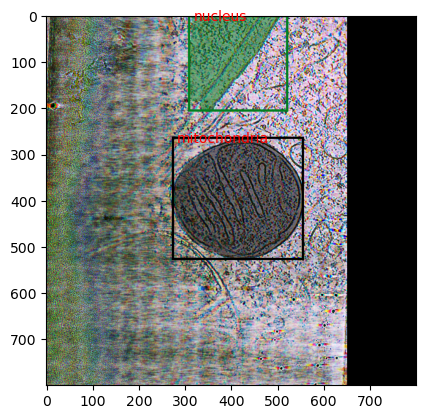

In [3]:
t = dataset[30]
# print(t["labels"])
# print("yes")
utils.drawannotation(t["pixel_values"].squeeze(0), t["labels"][0], mask=True, font_size=10)

In [3]:
path = "/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr_mrc_clean/fold1_mn"
with open(os.path.join(path, "config.json"), "r") as f:
    configs = json.load(f)
    
configs["model"]["stage"] = "stage 1 mask"
configs["model"]["mask_in_channels"] = 1
configs["training"]["scheduler_step"] = configs["training"]["epochs"][0] // 3
configs["training"]["lr_backbone"] = 4e-5
configs["training"]["lr_detr"] = 1e-4
configs["training"]["lr"] = 1e-4
configs["training"]["weight_decay"] = 0.0    

model = utils.getModel(configs).cuda(2)

Some weights of ConditionalDetrForObjectDetection were not initialized from the model checkpoint at microsoft/conditional-detr-resnet-50 and are newly initialized because the shapes did not match:
- class_labels_classifier.bias: found shape torch.Size([91]) in the checkpoint and torch.Size([2]) in the model instantiated
- class_labels_classifier.weight: found shape torch.Size([91, 256]) in the checkpoint and torch.Size([2, 256]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/home/feity/anaconda3/envs/pytorch/lib/python3.12/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


model at stage  stage 1 mask
model with output classes 3
model receiving class weights tensor([1.0000, 1.0000, 0.8000])
using consistency regularization coef 0.5


/home/feity/cryoem/utils.py:1088: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  t = torch.load(configs["model"]["load"], map_location="cpu")


incompatible parameters ['additional_input_layer.layer1.weight', 'additional_input_layer.layer1.bias', 'additional_input_layer.layer2.weight', 'additional_input_layer.layer2.bias', 'gnn.conv1.lin_l.weight', 'gnn.conv1.lin_l.bias', 'gnn.conv1.lin_r.weight', 'gnn.conv2.lin_l.weight', 'gnn.conv2.lin_l.bias', 'gnn.conv2.lin_r.weight', 'gnn.conv3.lin_l.weight', 'gnn.conv3.lin_l.bias', 'gnn.conv3.lin_r.weight', 'gnn.cls_head.0.weight', 'gnn.cls_head.0.bias', 'gnn.cls_head.2.weight', 'gnn.cls_head.2.bias', 'gnn.box_head.0.weight', 'gnn.box_head.0.bias', 'gnn.box_head.2.weight', 'gnn.box_head.2.bias', 'gnn.edge_head.0.weight', 'gnn.edge_head.0.bias', 'gnn.edge_head.2.weight', 'gnn.edge_head.2.bias', 'gnn.edge_head.4.weight', 'cri.weight']
finish loading parameters


In [4]:
model.box_loss.lambda_tv = 0.5
model.box_loss.lambda_noise = 0.1 
model.box_loss.lambda_dice = 1.0

In [5]:
# vit = modules.VitForMask(embed_dim=256)
# vit 
model.box_loss.warn = False

In [5]:
# optim = torch.optim.AdamW(model.parameters(), lr=configs["training"]["lr"], weight_decay=configs["training"]["weight_decay"])
model.stage = "stage 1 mask"
# model.lr_backbone = 0.0 
# model.lr_detr = 0.0
optim = model.configure_optimizers()[0][0]
cnt = 0 
for i in range(40):
    for j, d in enumerate(dataset):
        loss, loss_dict = model._common_step([d])
        optim.zero_grad()
        loss.backward()
        optim.step()
        cnt+=1
        if (cnt+1) % 50 == 0:
            print(loss_dict) 
    

{'loss_ce': tensor(1.0140), 'loss_bbox': tensor(0.1649), 'loss_giou': tensor(0.2883), 'cardinality_error': tensor(146.), 'loss': tensor(3.4290), 'mask_auroc': tensor(0.9884)}
{'loss_ce': tensor(1.0298), 'loss_bbox': tensor(0.0783), 'loss_giou': tensor(0.2379), 'cardinality_error': tensor(139.), 'loss': tensor(2.9269), 'mask_auroc': tensor(0.9882)}
{'loss_ce': tensor(1.1840), 'loss_bbox': tensor(0.0969), 'loss_giou': tensor(0.2257), 'cardinality_error': tensor(192.), 'loss': tensor(3.3040), 'mask_auroc': tensor(0.9923)}
{'loss_ce': tensor(0.8998), 'loss_bbox': tensor(0.0939), 'loss_giou': tensor(0.2091), 'cardinality_error': tensor(131.), 'loss': tensor(2.6872), 'mask_auroc': tensor(0.9898)}
{'loss_ce': tensor(1.3602), 'loss_bbox': tensor(0.0725), 'loss_giou': tensor(0.1344), 'cardinality_error': tensor(229.), 'loss': tensor(3.3520), 'mask_auroc': tensor(0.9840)}
{'loss_ce': tensor(0.8888), 'loss_bbox': tensor(0.2251), 'loss_giou': tensor(0.3458), 'cardinality_error': tensor(165.), 'los

In [6]:
func = modules.DetrModel.common_stage_mask
outside = []
def new_hook(self, pixel_values, embed, mask, cal_auroc=False, box=None):
    outside.append((pixel_values, embed, mask, box))
    return func(self, pixel_values, embed, mask, cal_auroc, box)
modules.DetrModel.common_stage_mask = new_hook

In [7]:
model.stage = "stage 1 mask"
model._common_step([d0])

(tensor(6.4240, device='cuda:2', grad_fn=<AddBackward0>),
 {'loss_ce': tensor(0.7315),
  'loss_bbox': tensor(0.0599),
  'loss_giou': tensor(0.1663),
  'cardinality_error': tensor(186.),
  'loss': tensor(2.0951),
  'mask_auroc': tensor(0.9951)})

In [ ]:
pixel_values, embed, mask, box = outside[0]
with torch.no_grad():
    # d["pixel_values"].shape, embeds.shape, boxes.shape
    model.stage = "stage mask" 
    mask = model(
        pixel_values=pixel_values.cuda(2), # d["pixel_values"].cuda(2).repeat(len(embeds), 1, 1, 1),
        # pixel_mask=d["pixel_mask"].cuda(2), 
        embed=embeds.cuda(2),

        box=boxes.cuda(2),)
    mask = torch.sigmoid(mask.squeeze()).detach().cpu().numpy()
    # )["pred_masks"].squeeze()

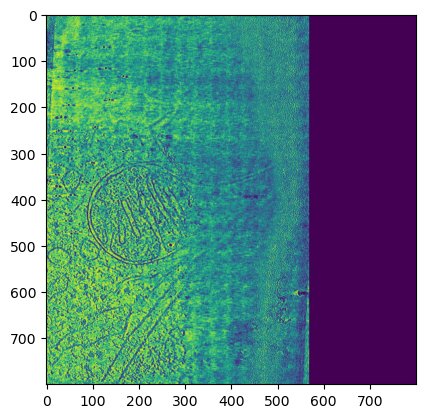

In [13]:
plt.imshow(pixel_values[0][1])

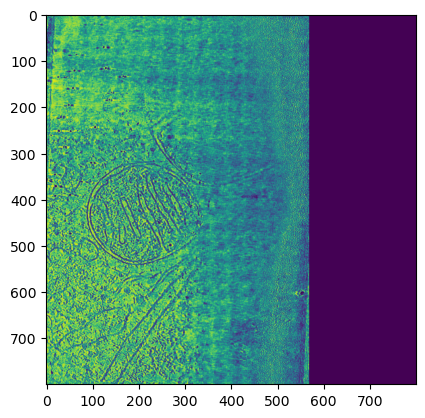

In [40]:
# d = dataset[30]
plt.imshow(d0["pixel_values"][0][1])

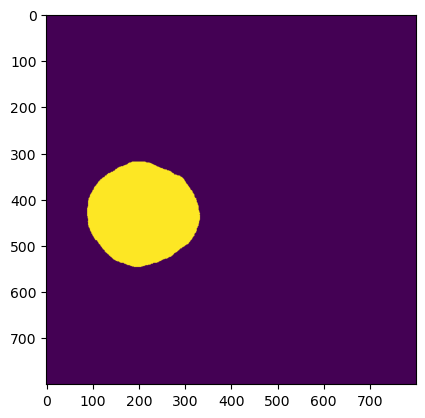

In [57]:
mask1 = d0["labels"][0]["masks"][0, 0].cpu().numpy()
plt.imshow(mask1)

In [41]:
with torch.no_grad():
    model.stage = "stage 1"
    output = model(
        pixel_values=d0["pixel_values"].cuda(2), 
        pixel_mask=d0["pixel_mask"].cuda(2), 
    )

    logits = output["logits"].squeeze()
    output.keys()

In [43]:
print(torch.max(logits[:, 0]))
need = logits[:, 0] > -0.4
embeds = output["last_hidden_state"].squeeze()[need]
boxes = output["pred_boxes"].squeeze()[need]
embeds.shape
torch.sum(need)

tensor(-0.3986, device='cuda:2')


tensor(1, device='cuda:2')

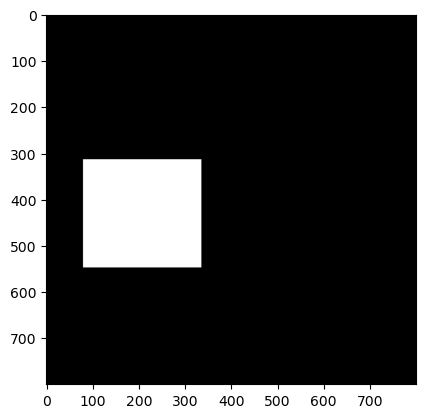

In [44]:
import postprocess 
boximage = postprocess.xywh2mask(
    boxes.squeeze().cpu().numpy(), 
    (800, 800)
)
boxes.shape
plt.imshow(boximage, cmap="gray")

In [45]:
with torch.no_grad():
    d["pixel_values"].shape, embeds.shape, boxes.shape
    model.stage = "stage mask" 
    mask = model(
        pixel_values=d["pixel_values"].cuda(2).repeat(len(embeds), 1, 1, 1),
        # pixel_mask=d["pixel_mask"].cuda(2), 
        embed=embeds.cuda(2),

        box=boxes.cuda(2),)
    mask = torch.sigmoid(mask.squeeze()).detach().cpu().numpy()
    # )["pred_masks"].squeeze()

In [46]:
mask.shape

(800, 800)

In [59]:
import numpy as np
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, jaccard_score
from scipy.stats import pearsonr
import cv2  # optional, for image reading

def evaluate_masks(mask1, mask2):
    """
    mask1: numpy array, first mask (predictions or object 1)
    mask2: numpy array, second mask (ground truth or object 2)
    Both masks should be binary (0/1) or probability [0-1]
    """

    # Flatten
    m1 = mask1.flatten()
    m2 = mask2.flatten()

    # Ensure both masks are same size
    assert m1.shape == m2.shape, "Masks must have the same shape."

    # If masks are not binary, binarize for discrete metrics
    bin1 = (m1 >= 0.5).astype(np.uint8)
    bin2 = (m2 >= 0.5).astype(np.uint8)

    # AUROC (works with continuous values)
    try:
        auroc = roc_auc_score(bin2, m1)  # using mask1 as scores, mask2 as true labels
    except ValueError:
        auroc = np.nan  # AUROC undefined if only one class present

    # Pearson correlation
    corr, _ = pearsonr(m1, m2)

    # Segmentation metrics (discrete masks)
    acc = accuracy_score(bin2, bin1)
    prec = precision_score(bin2, bin1, zero_division=0)
    rec = recall_score(bin2, bin1, zero_division=0)
    f1 = f1_score(bin2, bin1, zero_division=0)
    iou = jaccard_score(bin2, bin1, zero_division=0)

    results = {
        "AUROC": auroc,
        "Pearson Correlation": corr,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "IoU (Jaccard)": iou
    }
    return results


# if __name__ == "__main__":
#     # Example: load grayscale masks as numpy arrays
#     mask_pred = cv2.imread("pred_mask.png", cv2.IMREAD_GRAYSCALE) / 255.0
#     mask_gt   = cv2.imread("gt_mask.png", cv2.IMREAD_GRAYSCALE) / 255.0

#     metrics = evaluate_masks(mask_pred, mask_gt)

#     for k, v in metrics.items():
#         if v is None or np.isnan(v):
#             print(f"{k}: N/A")
#         else:
#             print(f"{k}: {v:.4f}")
evaluate_masks(mask, mask1)

{'AUROC': 0.9798850167578969,
 'Pearson Correlation': 0.7130239951820813,
 'Accuracy': 0.952378125,
 'Precision': 0.7252639042067118,
 'Recall': 0.4392833285618857,
 'F1-score': 0.5471591584452633,
 'IoU (Jaccard)': 0.376613282608251}

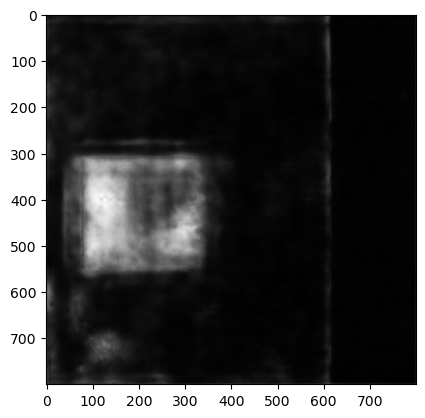

In [47]:
plt.imshow(mask, cmap="gray")

In [86]:
def sigmoid_focal_loss(
    inputs, targets, num_boxes=None, alpha: float = 0.25, gamma: float = 2
):
    """
    Loss used in RetinaNet for dense detection: https://arxiv.org/abs/1708.02002.

    Args:
        inputs (`torch.FloatTensor` of arbitrary shape):
            The predictions for each example.
        targets (`torch.FloatTensor` with the same shape as `inputs`)
            A tensor storing the binary classification label for each element in the `inputs` (0 for the negative class
            and 1 for the positive class).
        alpha (`float`, *optional*, defaults to `0.25`):
            Optional weighting factor in the range (0,1) to balance positive vs. negative examples.
        gamma (`int`, *optional*, defaults to `2`):
            Exponent of the modulating factor (1 - p_t) to balance easy vs hard examples.

    Returns:
        Loss tensor
    """
    prob = inputs.sigmoid()
    inputs = inputs.squeeze()
    targets = targets.squeeze()
    ce_loss = nn.functional.binary_cross_entropy_with_logits(
        inputs, targets, reduction="none"
    )
    # add modulating factor
    p_t = prob * targets + (1 - prob) * (1 - targets)
    loss = ce_loss * ((1 - p_t) ** gamma)
    print(loss)
    if alpha >= 0:
        alpha_t = alpha * targets + (1 - alpha) * (1 - targets)
        print(alpha_t)
        loss = alpha_t * loss
    print(loss)
    if num_boxes is None:
        num_boxes = targets.shape[0]

    return loss.mean(1).sum() / num_boxes

In [92]:
a = torch.tensor([[1.0, 1.0, 1.0, 1.0, 0.0]])
b = torch.tensor([[1.0, 1.0, 1.0, 1.0, -1.0]]) 
sigmoid_focal_loss(-b, 1-a, None, 0.25)

tensor([[0.0227, 0.0227, 0.0227, 0.0227, 0.0227]])
tensor([0.7500, 0.7500, 0.7500, 0.7500, 0.2500])
tensor([[0.0170, 0.0170, 0.0170, 0.0170, 0.0057]])


tensor(0.0029)

In [82]:
nn.functional.binary_cross_entropy_with_logits(
        -b, 1-a, reduction="none"
    )

tensor([[0.3133, 0.3133, 0.3133, 0.3133, 0.3133]])

### test naked GNN

In [ ]:
dataset = data.MrcDataset2(
    7, 
    "/data/transformer_project/transforemer_model/train_data/training/newdata/sllt0039.pkl",
    norm="hist",
    # map_class={"ribosome": 0, "mitochondria": 1, "nucleus": 2},
    reshape=800,
    gap=5,
    length_for_average=10,
    transform=data.getDefaultTransform(),
    add_classname=True,
)
model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr_mrc/whole_mask1_continue/","last.ckpt")
model = model.eval() 

dataset map classes:  {'ribosome': 0, 'mitochondria': 1, 'nucleus': 2, 'golgi': 3}


Some weights of ConditionalDetrForObjectDetection were not initialized from the model checkpoint at microsoft/conditional-detr-resnet-50 and are newly initialized because the shapes did not match:
- class_labels_classifier.bias: found shape torch.Size([91]) in the checkpoint and torch.Size([4]) in the model instantiated
- class_labels_classifier.weight: found shape torch.Size([91, 256]) in the checkpoint and torch.Size([4, 256]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model at stage  stage 1 + 2 + 3 mask
incompatible parameters []
finish loading parameters


In [6]:
# read dataset and run stage 1
model.stage = "stage 1"
# dataset = data.TestDataset("/data/transformer_project/transforemer_model/test_data/dxd20240920/tomo/24092002_9", norm="hist")
# dataset = data.CocoDetection(
# "/data/transformer_project/transforemer_model/train_data/training/data/",
# "/data/transformer_project/transforemer_model/train_data/training/data/annotations/sllt0039_9_5_10.pkl",
#                             is_npy=True, filter_class=[3, 4, 7, 12, 14], map_class={"3":0, "4":1, "7":2, "12":3, "14":4}, require_mask=True, transform=data.getConstantTransform(), add_classname=True, norm="hist",filtermin=3
# )
dataset = data.MrcDataset(
    "/data/transformer_project/transforemer_model/train_data/training/newdata/sllt0039.pkl",
    norm="hist",
    reshape=800,
    gap=5,
    length_for_average=10,
    transform=data.getConstantTransform(),
    add_classname=True,
    
)
# dataset = data.TestDatasetMrc("/data/transformer_project/transforemer_model/train_data/sull20240716_sllt0039/tomo/sllt0039_9.62Apx.mrc", norm="hist", reshape=800, gap=5, length_for_average=10)
retdict = utils.buildStage2(model, dataset, (800, 800), 0.05, has_none=False, empty=4)
graph = utils.convertStage2Dataset(retdict, num_classes=4)

dataset map classes:  {'ribosome': 0, 'mitochondria': 1, 'nucleus': 2, 'golgi': 3}
slice 0
check whether reserve  tensor(252) tensor(252)
torch.Size([252]) torch.Size([252, 4])
obj_cnts: 252
slice 1
check whether reserve  tensor(246) tensor(246)
torch.Size([246]) torch.Size([246, 4])
obj_cnts: 498
slice 2
check whether reserve  tensor(236) tensor(236)
torch.Size([236]) torch.Size([236, 4])
obj_cnts: 734
slice 3
check whether reserve  tensor(235) tensor(235)
torch.Size([235]) torch.Size([235, 4])
obj_cnts: 969
slice 4
check whether reserve  tensor(231) tensor(231)
torch.Size([231]) torch.Size([231, 4])
obj_cnts: 1200
slice 5
check whether reserve  tensor(221) tensor(221)
torch.Size([221]) torch.Size([221, 4])
obj_cnts: 1421
slice 6
check whether reserve  tensor(234) tensor(234)
torch.Size([234]) torch.Size([234, 4])
obj_cnts: 1655
slice 7
check whether reserve  tensor(225) tensor(225)
torch.Size([225]) torch.Size([225, 4])
obj_cnts: 1880
slice 8
check whether reserve  tensor(226) tensor

In [17]:
model = modules.GCN(256, 265, 5, "TransformerConv", True).cuda(2)
auroc = torchmetrics.AUROC("multiclass", average="macro", num_classes=5).cuda(1)
optim = torch.optim.Adam(model.parameters(), lr=0.0005) 
loss_func = nn.CrossEntropyLoss()
mse = nn.MSELoss()

In [179]:
class SimpleModel(nn.Module):
    def __init__(self):
        super(SimpleModel, self).__init__()
        self.l1 = nn.Linear(266, 512)
        self.l2 = nn.Linear(512, 6)

    def forward(self, input, y):
        x = self.l1(input)
        x = torch.relu(x)
        x = self.l2(x)
        # x = nn.functional.softmax(x)
        return {"predict":x}
model = SimpleModel().cuda(1)

In [6]:
graph_train = torch.load("/data/transformer_project/transforemer_model/train_data/training/data/stage2/fold1_sllt0051_9_stage2dataset.pkl") 
retdict_train = torch.load("/data/transformer_project/transforemer_model/train_data/training/data/stage2/fold1_sllt0051_9_stage2dict.pkl")

/tmp/ipykernel_1899518/1068036701.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  graph_train = torch.load("/data/transformer_project/transforemer_model/train_data/train

In [7]:
graph_test = torch.load("/data/transformer_project/transforemer_model/train_data/training/data/stage2/fold1_sllt0039_9_stage2dataset.pkl") 
retdict_test = torch.load("/data/transformer_project/transforemer_model/train_data/training/data/stage2/fold1_sllt0039_9_stage2dict.pkl")

/tmp/ipykernel_1899518/4260404348.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  graph_test = torch.load("/data/transformer_project/transforemer_model/train_data/traini

In [8]:
def get_data(graph, retdict, device=None):
    x = graph.x
    box_masks = graph.box_masks
    edge_index = graph.edge_index
    target = retdict["boxes"] 
    target_y = graph.y
    target = target[box_masks]
    if device is not None:
        x = x.to(device)
        box_masks = box_masks.to(device)
        edge_index = edge_index.to(device)
        target = target.to(device)
        target_y = target_y.to(device)
    return x, box_masks, edge_index, target, target_y



In [ ]:

x, box_masks, edge_index, target, target_y = get_data(graph_train, retdict_train, device=0)           
# loss_func = partial(modules.loss _boxes, num_boxes=4)
# loss_func = nn.MSELoss()
loss_func = nn.CrossEntropyLoss()
mse = nn.MSELoss()

In [10]:
target_y.shape

torch.Size([7765])

In [12]:
ori = torch.ones((x.shape[0], 6)).cuda(0)
ori -= 0.5 
ori[:, :5] = x[:, 5:10]
loss_func(ori, target_y), auroc(ori, target_y)

(tensor(0.4623, device='cuda:0'), tensor(0.8758, device='cuda:0'))

In [19]:
graph

Data(x=[12003, 265], edge_index=[2, 188908], y=[12003], box_masks=[12003], boxes=[12003, 4])

In [20]:
graph.x = graph.x.cuda(2)
graph.box_masks = graph.box_masks.cuda(2)
graph.boxes = graph.boxes.cuda(2)
graph.edge_index = graph.edge_index.cuda(2)
graph.y = graph.y.cuda(2)

In [23]:
losses = []
for i in range(2000):
    optim.zero_grad()
    out = model(graph.x, graph.edge_index)   
    loss = loss_func(out["predict"], graph.y)
    loss += mse(out["box"][graph.box_masks], graph.boxes[graph.box_masks])
    loss.backward()
    optim.step()
    losses.append(loss.item())
    # print(loss.item())
    if i % 20 == 0:
        print(loss.item(), mse(out["box"][graph.box_masks], graph.boxes[graph.box_masks]).item(), auroc(out["predict"], graph.y))
        # torch.save(model.state_dict(), "/data/transformer_project/transforemer_model/train_data/training/data/stage2/fold1_sllt0039_9_stage2dataset.pkl")
        # torch.save(graph, "/data/transformer_project/transforemer_model/train_data/training/data/stage2/fold1_sllt0039_9_stage2dict.pkl")

1.6008669137954712 0.00014787759573664516 tensor(0.3460, device='cuda:2')
0.2657002806663513 0.00014039473899174482 tensor(0.8984, device='cuda:2')
0.24058420956134796 0.00013811205280944705 tensor(0.9141, device='cuda:2')
0.22508281469345093 0.00013594244956038892 tensor(0.9232, device='cuda:2')
0.18668842315673828 0.000133173365611583 tensor(0.9455, device='cuda:2')
0.16705499589443207 0.00012878245615866035 tensor(0.9595, device='cuda:2')
0.1547737717628479 0.0001265900064026937 tensor(0.9651, device='cuda:2')
0.14383749663829803 0.00012711453018710017 tensor(0.9702, device='cuda:2')
0.1351212114095688 0.00012337512453086674 tensor(0.9733, device='cuda:2')
0.12889181077480316 0.00012152449926361442 tensor(0.9759, device='cuda:2')
0.12122136354446411 0.00012169869296485558 tensor(0.9789, device='cuda:2')
0.11218638718128204 0.00012064175098203123 tensor(0.9823, device='cuda:2')
0.10389161854982376 0.00011772443394875154 tensor(0.9850, device='cuda:2')
0.10535617917776108 0.0001206166

In [189]:
x, box_masks, edge_index, target, target_y = get_data(graph_test, retdict_test, device=1)
# ori = x[box_masks]
# ori = ori[:, 1:5]
# modules.loss_boxes(ori, target, 2)

In [191]:
model = model.eval()
out = model(x, edge_index)   
loss_func(out["predict"], target_y), auroc(out["predict"], target_y)
# modules.loss_boxes(out["box"][box_masks], target, 3)

(tensor(0.9972, device='cuda:1', grad_fn=<NllLossBackward0>),
 tensor(0.6949, device='cuda:1'))

## test small batch

In [2]:
path = "/data/transformer_project/transforemer_model/train_data/training/results/deformable/fold6_pretrain_test/"
with open(os.path.join(path, "config.json"), "r") as f:
    configs = json.load(f)
# configs["data"]["image_path"] = "/mnt/panbz/lab/transforemer_model/train_data/training/data/"
# configs["data"]["annotation_path_train"] = "/mnt/panbz/lab/transforemer_model/train_data/training/data/annotations/sllt0039_9.pkl"
# configs["data"]["annotation_path_val"] = "/mnt/panbz/lab/transforemer_model/train_data/training/data/annotations/sllt0051_9.pkl"

In [3]:
if configs["model"]["stage"] == "stage 1":
    ds = utils.get_stage1_dataset(configs)
elif configs["model"]["stage"] == "stage 2":
    ds = utils.get_stage2_dataset(configs)
elif configs["model"]["stage"] == "stage mask":
    ds = utils.get_stageMask_dataset(configs)

loading annotations into memory...
Done (t=0.11s)
creating index...
index created!
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!


In [4]:
model = utils.getModel(configs)

Some weights of the model checkpoint at SenseTime/deformable-detr were not used when initializing DeformableDetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DeformableDetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DeformableDetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of DeformableDetrForObjectDetection wer

model at stage  stage 1


/home/feity/cryoem/utils.py:496: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  t = torch.load(configs["model"]["load"], map_location="cpu")


incompatible parameters ['model.class_embed.0.weight', 'model.class_embed.0.bias', 'model.class_embed.1.weight', 'model.class_embed.1.bias', 'model.class_embed.2.weight', 'model.class_embed.2.bias', 'model.class_embed.3.weight', 'model.class_embed.3.bias', 'model.class_embed.4.weight', 'model.class_embed.4.bias', 'model.class_embed.5.weight', 'model.class_embed.5.bias']
finish loading parameters


In [5]:
dl = ds.train_dataloader()
for i, j in enumerate(dl):
    break

In [ ]:
optim = model.configure_optimizers() 
optim = optim[0][0]

[AdamW (
 Parameter Group 0
     amsgrad: False
     betas: (0.9, 0.999)
     capturable: False
     differentiable: False
     eps: 1e-08
     foreach: None
     fused: None
     initial_lr: 0.0001
     lr: 0.0001
     maximize: False
     weight_decay: 1e-05
 
 Parameter Group 1
     amsgrad: False
     betas: (0.9, 0.999)
     capturable: False
     differentiable: False
     eps: 1e-08
     foreach: None
     fused: None
     initial_lr: 0.0001
     lr: 0.0001
     maximize: False
     weight_decay: 1e-05
 
 Parameter Group 2
     amsgrad: False
     betas: (0.9, 0.999)
     capturable: False
     differentiable: False
     eps: 1e-08
     foreach: None
     fused: None
     initial_lr: 0.0001
     lr: 0.0001
     maximize: False
     weight_decay: 1e-05
 )]

In [ ]:
model = model.cuda(0)
for i in range(2000):
    optim.zero_grad()
    loss, loss_dict = model.common_step_stage1(j) 
    loss.backward()
    optim.step()
    if i % 10 == 0:
        print(loss_dict)

### test stage2

In [3]:
graph = torch.load("/data/transformer_project/transforemer_model/train_data/training/data/stage2/fold1_sllt0039_9_stage2dataset.pkl") 
retdict = torch.load("/data/transformer_project/transforemer_model/train_data/training/data/stage2/fold1_sllt0039_9_stage2dict.pkl")
# model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/deformable/fold1_stage2_424", "epoch=199-validate_loss=3.5734-validate_acc=0.9490.ckpt")

/tmp/ipykernel_84582/2483119653.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  graph = torch.load("/data/transformer_project/transforemer_model/train_data/training/data

In [ ]:
path = "/data/transformer_project/transforemer_model/train_data/training/results/deformable/fold1_stage2_424"
with open(os.path.join(path, "config.json"), "r") as f:
    configs = json.load(f)
model = utils.getModel(configs)

In [14]:
graph

Data(x=[5908, 266], edge_index=[2, 138028], y=[5908], box_masks=[5908], boxes=[5908, 4], edge_label=[138028])

In [6]:
x = graph.x
y = graph.y 
edge = graph.edge_index
box_masks = graph.box_masks
edge_labels = graph.edge_label
mask = torch.ones_like(y, dtype=torch.bool)
boxes = graph.boxes

In [7]:
optim = model.configure_optimizers() 
optim = optim[0][0]

In [8]:
model = model.cuda(0)
for i in range(2000):
    optim.zero_grad()
    loss, loss_dict = model.common_step_stage2(x, edge, mask, y, boxes, box_masks, edge_labels) 
    loss.backward()
    optim.step()
    if i % 10 == 0:
        print(loss_dict)

{'loss': tensor(6.3627, device='cuda:0', grad_fn=<AddBackward0>), 'acc': tensor(0.0125, device='cuda:0'), 'loss_boxes': tensor(3.7667, device='cuda:0', grad_fn=<AddBackward0>), 'loss_edge': tensor(0.7223, device='cuda:0', grad_fn=<BinaryCrossEntropyBackward0>)}
{'loss': tensor(5.8498, device='cuda:0', grad_fn=<AddBackward0>), 'acc': tensor(0.9100, device='cuda:0'), 'loss_boxes': tensor(3.6927, device='cuda:0', grad_fn=<AddBackward0>), 'loss_edge': tensor(0.5258, device='cuda:0', grad_fn=<BinaryCrossEntropyBackward0>)}
{'loss': tensor(4.6660, device='cuda:0', grad_fn=<AddBackward0>), 'acc': tensor(0.9103, device='cuda:0'), 'loss_boxes': tensor(3.5686, device='cuda:0', grad_fn=<AddBackward0>), 'loss_edge': tensor(0.1251, device='cuda:0', grad_fn=<BinaryCrossEntropyBackward0>)}
{'loss': tensor(3.8482, device='cuda:0', grad_fn=<AddBackward0>), 'acc': tensor(0.9103, device='cuda:0'), 'loss_boxes': tensor(3.6013, device='cuda:0', grad_fn=<AddBackward0>), 'loss_edge': tensor(0.0168, device='c

In [1]:

import mrcfile 
import numpy as np
import torchvision.datasets
import datetime
import os
import torch
from tqdm import tqdm
from torch.utils.data import DataLoader
# import transformers
import pytorch_lightning as pl
# import supervision as sv
from transformers import DetrConfig, DetrForObjectDetection, DetrImageProcessor, DetrForSegmentation, ConditionalDetrForObjectDetection
import torch
import sys 
sys.path.append("/home/tyfei/cyroem")
import importlib 
import utils
import matplotlib.pyplot as plt
from torchvision.transforms import v2
import modules
importlib.reload(utils)
importlib.reload(modules)

/home/feity/anaconda3/envs/pytorch/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'modules' from '/home/feity/cryoem/modules.py'>

In [2]:
import torchvision
torchvision.disable_beta_transforms_warning()
from torchvision.tv_tensors import BoundingBoxes, Mask
from torchvision.utils import draw_bounding_boxes, draw_segmentation_masks
import torchvision.transforms.v2  as transforms
from functools import partial
import numpy as np
import sys 
import os
sys.path.append("/home/tyfei/cyroem")
import utils
import pycocotools
import json
import torch
import pickle
import matplotlib.pyplot as plt
import pandas as pd
from transformers import DetrForObjectDetection, DetrImageProcessor, DetrForSegmentation
import modules
from torch_geometric.data import Data 

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class SelfAttention(nn.Module):
    def __init__(self, channels, size, pos_embed=16):
        super(SelfAttention, self).__init__()
        self.channels = channels
        self.size = size
        self.mha = nn.MultiheadAttention(channels + pos_embed, 4, batch_first=True)
        self.pos = nn.Parameter(torch.randn(1, size * size, pos_embed))
        # self.l1 = nn.Linear(channels + pos_embed, channels)
        # self.ln = nn.LayerNorm([channels])
        self.ff_self = nn.Sequential(
            nn.LayerNorm([channels + pos_embed]),
            nn.Linear(channels + pos_embed, channels),
            nn.GELU(),
            nn.Linear(channels, channels),
        )

    def forward(self, x):
        x = x.view(-1, self.channels, self.size * self.size).swapaxes(1, 2)
        # x_ln = self.ln(x)
        x_ln = torch.cat([x_ln, self.pos.repeat(x.shape[0], 1, 1)], dim=-1)

        attention_value, _ = self.mha(x_ln, x_ln, x_ln)
        # attention_value = self.l1(attention_value)
        attention_value = attention_value # + x
        attention_value = self.ff_self(attention_value) # + attention_value
        return attention_value.swapaxes(2, 1).view(
            -1, self.channels, self.size, self.size
        )


class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, mid_channels=None, residual=False):
        super().__init__()
        self.residual = residual
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(1, mid_channels),
            nn.GELU(),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(1, out_channels),
        )

    def forward(self, x):
        if self.residual:
            return F.gelu(x + self.double_conv(x))
        else:
            return self.double_conv(x)


class Down(nn.Module):
    def __init__(self, in_channels, out_channels, emb_dim=256, pool_kernal=2):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(pool_kernal),
            # DoubleConv(in_channels, in_channels, residual=True),
            DoubleConv(in_channels, out_channels),
        )

        self.emb_layer = nn.Sequential(
            nn.Linear(emb_dim, out_channels),
            nn.SiLU(),
        )

    def forward(self, x, t):
        x = self.maxpool_conv(x)
        emb = self.emb_layer(t)[:, :, None, None].repeat(1, 1, x.shape[-2], x.shape[-1])
        return x + emb


class Up(nn.Module):
    def __init__(self, in_channels, out_channels, size, emb_dim=None):
        super().__init__()

        self.up = nn.Upsample(size=size, mode="bilinear", align_corners=True)
        self.conv = nn.Sequential(
            # DoubleConv(in_channels, in_channels, residual=True),
            DoubleConv(in_channels, out_channels, in_channels),
        )
        if emb_dim is not None:
            self.emb_layer = nn.Sequential(
                nn.Linear(emb_dim, out_channels),
                nn.SiLU(),
            )

    def forward(self, x, skip_x, t = None):
        x = self.up(x)
        x = torch.cat([skip_x, x], dim=1)
        x = self.conv(x)
        if t is None:
            return x

        emb = self.emb_layer(t)[:, :, None, None].repeat(1, 1, x.shape[-2], x.shape[-1])
        return x + emb


class UNet(nn.Module):
    def __init__(self, c_in=3, embed_dim=256, patch_size = 8, sigmoid=True):
        super().__init__()
        
        # 3 * 800 * 800
        self.down1 = Down(c_in, 8, embed_dim, 2) 
        
        # 8 * 400 * 400
        self.down2 = Down(8, 16, embed_dim, 2)

        self.patch_embed = nn.Conv2d(16, 128, kernel_size=patch_size, stride=patch_size)
        self.pos_embed = nn.Parameter(torch.zeros(1, 626, 128))
        self.l = nn.Sequential(nn.Linear(embed_dim, 128), nn.SiLU())
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model = 128, 
                nhead = 8,
                dim_feedforward=512,
                dropout=0.1, 
                activation="gelu",
            ),
            num_layers=6,
        )
        # 256 * 12 * 12

        # 64 * 200 * 200
        self.up3 = Up(128+16, 32, (200, 200), embed_dim)

        # 32 * 800 * 800
        self.up2 = Up(32+8, 4, (400, 400), embed_dim)

        # 1 * 800 * 800
        self.up1 = Up(4+3, 1, (800, 800))
        
        self.sigmoid = sigmoid

    def forward(self, x0, t):
        B, C, _, _ = x0.shape
        x1 = self.down1(x0, t) 
        x2 = self.down2(x1, t)
        s = self.l(t) 
        x3 = self.patch_embed(x2)
        x3 = x3.flatten(2).transpose(1, 2)
        x3 = torch.cat((s.unsqueeze(1), x3), dim=1) 
        x3 = x3 + self.pos_embed 
        
        x = self.transformer(x3) 
        x = x[:, 1:, :]
        x = x.transpose(1, 2).reshape(B, 128, 25, 25)
        
        x = self.up3(x, x2, t)
        x = self.up2(x, x1, t)
        x = self.up1(x, x0)
        
        x = x.squeeze(1)
        if self.sigmoid:
            output = torch.sigmoid(x)
        return output


if __name__ == "__main__":
    # Create the U-Net model with additional input
    model = UNet(c_in=3, embed_dim=256).cuda(1)

    # Create a random input tensor with size (batch_size=1, channels=3, height=800, width=800)
    input_tensor = torch.randn(40, 3, 800, 800).cuda(1)

    # Create a random additional input tensor with size (batch_size=1, additional_input_dim=10)
    additional_input = torch.randn(40, 256).cuda(1)

    # Perform a forward pass
    output = model(input_tensor, additional_input)

    # Check the output size
    print("Input shape: ", input_tensor.shape)
    print("Additional input shape: ", additional_input.shape)
    print("Output shape:", output.shape)

OutOfMemoryError: CUDA out of memory. Tried to allocate 196.00 MiB. GPU 1 has a total capacity of 23.65 GiB of which 159.69 MiB is free. Including non-PyTorch memory, this process has 23.48 GiB memory in use. Of the allocated memory 22.43 GiB is allocated by PyTorch, and 612.32 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class UNetWithAdditionalInput(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, additional_input_dim=10):
        super(UNetWithAdditionalInput, self).__init__()

        # Contracting path (Encoder)
        self.enc1 = self.double_conv(in_channels, 32)
        self.enc2 = self.double_conv(32, 64)
        self.enc3 = self.double_conv(64, 128)
        self.enc4 = self.double_conv(128, 256)

        # Bottleneck
        self.bottleneck = self.double_conv(256, 512)

        # Process additional input
        self.additional_fc = nn.Sequential(
            nn.Linear(additional_input_dim, 512),  # Map additional input to the same dimension as bottleneck
            # nn.ReLU(inplace=True)
        )

        # Expanding path (Decoder)
        self.upconv4 = self.upconv(1024, 256)  # Bottleneck + Additional input (1024 + 1024 = 2048)
        self.dec4 = self.double_conv(512, 256)

        self.upconv3 = self.upconv(256, 128)
        self.dec3 = self.double_conv(256, 128)

        self.upconv2 = self.upconv(128, 64)
        self.dec2 = self.double_conv(128, 64)

        self.upconv1 = self.upconv(64, 32)
        self.dec1 = self.double_conv(64, 32)

        # Output layer
        self.out_conv = nn.Conv2d(32, out_channels, kernel_size=1)

    def double_conv(self, in_channels, out_channels):
        """Double convolution layers with ReLU activation."""
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU6(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU6(inplace=True)
        )

    def upconv(self, in_channels, out_channels):
        """Upsample the feature map using transpose convolution."""
        return nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)

    def crop_and_concat(self, upsampled, bypass):
        """Crop the bypass connection to match the size of the upsampled feature map."""
        _, _, h, w = upsampled.size()
        bypass = F.interpolate(bypass, size=(h, w), mode="bilinear", align_corners=True)
        return torch.cat((upsampled, bypass), dim=1)

    def forward(self, x, additional_input):
        # Encoder
        enc1 = self.enc1(x)
        print(enc1.shape)
        enc2 = self.enc2(F.max_pool2d(enc1, kernel_size=2))
        print(enc2.shape)
        enc3 = self.enc3(F.max_pool2d(enc2, kernel_size=2))
        print(enc3.shape)
        enc4 = self.enc4(F.max_pool2d(enc3, kernel_size=2))
        print(enc4.shape)

        # Bottleneck
        bottleneck = self.bottleneck(F.max_pool2d(enc4, kernel_size=2))
        print(bottleneck.shape)
        # Process additional input
        additional_input_processed = self.additional_fc(additional_input)
        additional_input_processed = additional_input_processed.unsqueeze(-1).unsqueeze(-1)  # Reshape to (batch, 1024, 1, 1)
        additional_input_processed = additional_input_processed.expand(-1, -1, bottleneck.size(2), bottleneck.size(3))  # Match spatial dims

        # Concatenate bottleneck and additional input
        bottleneck = torch.cat((bottleneck, additional_input_processed), dim=1)
        print("bottlecek shape", bottleneck.shape)
        # Decoder
        up4 = self.upconv4(bottleneck)
        concat4 = self.crop_and_concat(up4, enc4)
        print(concat4.shape)
        dec4 = self.dec4(concat4)

        up3 = self.upconv3(dec4)
        concat3 = self.crop_and_concat(up3, enc3)
        print(concat3.shape)    
        dec3 = self.dec3(concat3)

        up2 = self.upconv2(dec3)
        concat2 = self.crop_and_concat(up2, enc2)
        print(concat2.shape)
        dec2 = self.dec2(concat2)

        up1 = self.upconv1(dec2)
        concat1 = self.crop_and_concat(up1, enc1)
        print(concat1.shape)
        dec1 = self.dec1(concat1)

        # Output layer
        output = self.out_conv(dec1)
        output = output.squeeze(1)  # Remove channel dimension
        # output = torch.sigmoid(output)  # Sigmoid activation for binary classification
        return output

# Test the modified U-Net model
if __name__ == "__main__":
    # Create the U-Net model with additional input
    model = UNetWithAdditionalInput(in_channels=3, out_channels=1, additional_input_dim=256).cuda(1)

    # Create a random input tensor with size (batch_size=1, channels=3, height=800, width=800)
    input_tensor = torch.randn(20, 3, 400, 400).cuda(1)

    # Create a random additional input tensor with size (batch_size=1, additional_input_dim=10)
    additional_input = torch.randn(20, 256).cuda(1)

    # Perform a forward pass
    output = model(input_tensor, additional_input)

    # Check the output size
    print("Input shape: ", input_tensor.shape)
    print("Additional input shape: ", additional_input.shape)
    print("Output shape:", output.shape)


torch.Size([20, 32, 400, 400])
torch.Size([20, 64, 200, 200])
torch.Size([20, 128, 100, 100])
torch.Size([20, 256, 50, 50])
torch.Size([20, 512, 25, 25])
bottlecek shape torch.Size([20, 1024, 25, 25])
torch.Size([20, 512, 50, 50])
torch.Size([20, 256, 100, 100])
torch.Size([20, 128, 200, 200])
torch.Size([20, 64, 400, 400])
Input shape:  torch.Size([20, 3, 400, 400])
Additional input shape:  torch.Size([20, 256])
Output shape: torch.Size([20, 400, 400])


In [1]:
import importlib
import modules
import utils
import torch
import torch.nn as nn
# model = modules.UNet(3, 1, 272, False)
# model(input_tensor, additional_input)

/home/feity/anaconda3/envs/pytorch/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
a = torch.load("/data/transformer_project/transforemer_model/train_data/training/data/stage2/fold1_sllt0039_9_stage2dataset_stage12_507_mask.pkl",)
a.keys()

/tmp/ipykernel_2205078/3939119741.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  a = torch.load("/data/transformer_project/transforemer_model/train_data/training/data/s

dict_keys(['pixel_values', 'embed', 'masks', 'sample_mapping'])

In [3]:
need = []
for i in a["sample_mapping"]:
    if a["sample_mapping"][i] == 15:
        need.append(i)

In [4]:
masks = a["masks"]
masks = masks[need]
embeds = a["embed"]
embeds = embeds[need]

In [5]:
s = masks.sum(axis=[1, 2])
masks = masks[s>1000]#.to(1)
embed = embeds[s>1000]#.to(1)
s = masks.sum(axis=[1, 2])
masks = masks[s<18000].to("cpu")
embed = embed[s<18000].to("cpu")

In [6]:
masks.shape

torch.Size([3, 800, 800])

In [7]:
pixel_values = a["pixel_values"][15] 
pixel_values = pixel_values.unsqueeze(0).repeat(3, 1, 1, 1).to("cpu")

In [17]:
pixel_values = pixel_values.cuda(3)
embed = embed.cuda(3)
masks = masks.cuda(3)

In [9]:
def focal_loss(inputs, targets, alpha: float = 0.75, gamma: float = 2.0):
    ce_loss = F.binary_cross_entropy(inputs, targets, reduction="none")
        # add modulating factor
    p_t = inputs.detach() * targets + (1 - inputs.detach()) * (1 - targets)
    loss = ce_loss * ((1 - p_t) ** gamma)

    if alpha >= 0:
        alpha_t = alpha * targets + (1 - alpha) * (1 - targets)
        loss = alpha_t * loss

    return loss.sum()

In [10]:
def sigmoid_focal_loss(inputs, targets, num_boxes=None, alpha: float = 0.25, gamma: float = 2):
    """
    Loss used in RetinaNet for dense detection: https://arxiv.org/abs/1708.02002.

    Args:
        inputs (`torch.FloatTensor` of arbitrary shape):
            The predictions for each example.
        targets (`torch.FloatTensor` with the same shape as `inputs`)
            A tensor storing the binary classification label for each element in the `inputs` (0 for the negative class
            and 1 for the positive class).
        alpha (`float`, *optional*, defaults to `0.25`):
            Optional weighting factor in the range (0,1) to balance positive vs. negative examples.
        gamma (`int`, *optional*, defaults to `2`):
            Exponent of the modulating factor (1 - p_t) to balance easy vs hard examples.

    Returns:
        Loss tensor
    """
    prob = inputs.sigmoid()
    ce_loss = nn.functional.binary_cross_entropy_with_logits(inputs, targets, reduction="none")
    # add modulating factor
    p_t = prob * targets + (1 - prob) * (1 - targets)
    loss = ce_loss * ((1 - p_t) ** gamma)

    if alpha >= 0:
        alpha_t = alpha * targets + (1 - alpha) * (1 - targets)
        loss = alpha_t * loss
        
    if num_boxes is None:
        num_boxes = targets.shape[0]

    return loss.mean(1).sum() / num_boxes

In [35]:
import Unet
importlib.reload(Unet)
model = modules.ViTSegmentation(embed_dim=272, sigmoid=False)
# model = UNetWithAdditionalInput(3, 1, 272)
opt = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3)
model = model.to(3)
# cri = focal_loss  
losses_Unet5 = []
cri = nn.BCELoss()
for i in range(900):
    
    opt.zero_grad()
    out = model(pixel_values.float().detach(), embed.detach())
    # loss = nn.functional.binary_cross_entropy_with_logits(out, masks.float().detach())
    loss = sigmoid_focal_loss(out, masks.float().detach(), 6, alpha=0.75)
    loss.backward()
    opt.step()
    if i % 10 == 0:
        print(loss.item())
        losses_Unet5.append(loss.item())

18.031919479370117
2.5172064304351807
2.289355754852295
2.1804094314575195
2.1372973918914795
2.110302686691284
2.098320960998535
2.076678991317749
2.0645337104797363
2.045610189437866
2.0348520278930664
2.0161194801330566
1.9949935674667358
1.9848830699920654
1.985854148864746
1.9699537754058838
1.967463493347168
1.9580634832382202
1.9511456489562988
1.949934482574463
1.9425580501556396
1.9307219982147217
1.8498740196228027
2.441100597381592
1.9574602842330933
1.9795783758163452
1.9322106838226318
1.933837652206421
1.9232391119003296
1.925873041152954
1.9222562313079834
1.9085075855255127
1.9087027311325073
1.9044158458709717
1.9049537181854248
1.8854484558105469
1.8945444822311401
1.8804948329925537
1.8854469060897827
1.875835657119751
1.8713735342025757
1.8586821556091309
1.858222246170044
1.8506221771240234
1.8450978994369507
1.8554080724716187
1.834011435508728
1.8231090307235718
1.8142006397247314
1.8131922483444214
1.7942746877670288
1.7855634689331055
1.7737315893173218
1.76414

In [33]:
import Unet
importlib.reload(Unet)
model = modules.UNet6(embed_dim=272, sigmoid=False)
# model = UNetWithAdditionalInput(3, 1, 272)
opt = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3)
model = model.to(3)
# cri = focal_loss  
losses_Unet5 = []
cri = nn.BCELoss()
for i in range(400):
    
    opt.zero_grad()
    out = model(pixel_values.float().detach(), embed.detach())
    # loss = nn.functional.binary_cross_entropy_with_logits(out, masks.float().detach())
    loss = sigmoid_focal_loss(out, masks.float().detach(), 6, alpha=0.75)
    loss.backward()
    opt.step()
    if i % 10 == 0:
        print(loss.item())
        losses_Unet5.append(loss.item())

/home/feity/anaconda3/envs/pytorch/lib/python3.12/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


70.60682678222656
7.276630401611328
2.935239791870117
2.207775831222534
2.0966286659240723
2.0845603942871094
2.079270362854004
2.0703775882720947
2.0595483779907227
2.043666124343872
2.0174617767333984
1.983778476715088
1.9187090396881104
1.8437080383300781
1.7862142324447632
1.5588539838790894
1.457289695739746
1.2971985340118408
1.5459258556365967
1.2235949039459229
1.1369435787200928
1.007722020149231
0.8721774816513062
0.6784716844558716
0.5562935471534729
1.602818489074707
0.7490177154541016
0.5606994032859802
0.36867159605026245
0.25882843136787415
0.18483339250087738
0.15591301023960114
0.12250404059886932
0.11083655059337616
0.1122063398361206
0.09015381336212158
0.08272670209407806
0.07756602019071579
0.0720779150724411
0.06708139181137085


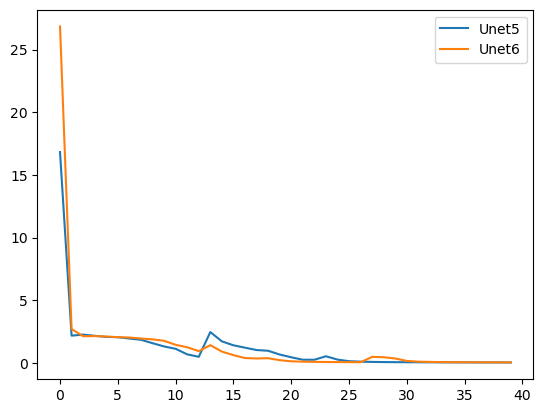

In [22]:
import matplotlib.pyplot as plt 
plt.plot(losses_Unet5, label="Unet5")
plt.plot(losses_Unet6, label="Unet6")
plt.legend()

In [13]:
importlib.reload(modules)
model = modules.UNet5(embed_dim=272, sigmoid = False)
# model = UNetWithAdditionalInput(3, 1, 272)
opt = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3)
model = model.to(3)
# cri = focal_loss  
cri = nn.BCELoss()
for i in range(400):
    opt.zero_grad()
    out = model(pixel_values.float().detach(), embed.detach())
    # loss = nn.functional.binary_cross_entropy_with_logits(out, masks.float().detach())
    loss = sigmoid_focal_loss(out, masks.float().detach(), 6, alpha=0.75)
    loss.backward()
    opt.step()
    if i % 10 == 0:
        print(loss.item())

6.666089057922363
2.179352283477783
2.1785454750061035
1.9743022918701172
1.5989131927490234
1.248558521270752
1.5373082160949707
1.0450457334518433
0.7465888857841492
0.4755459427833557
1.0518691539764404
0.5735061764717102
0.4159579873085022
0.25498414039611816
0.11105155944824219
0.0784735456109047
0.062202394008636475
0.05080892890691757
0.04398179054260254
0.03959430381655693
0.03668787330389023
0.03386634215712547
0.03184577077627182
0.030052024871110916
0.028438091278076172
0.02704544924199581
0.026074212044477463
0.024990759789943695
0.023911476135253906
0.023073725402355194
0.022667095065116882
0.022460907697677612
0.02103363536298275
0.020842596888542175
0.021865731105208397
0.019955314695835114
0.02067188173532486
0.028148021548986435
0.035464003682136536
0.02252107858657837


In [13]:
importlib.reload(modules)
model = modules.UNet2(embed_dim=272, sigmoid = False)
# model = UNetWithAdditionalInput(3, 1, 272)
opt = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3)
model = model.to(3)
# cri = focal_loss  
cri = nn.BCELoss()
for i in range(512):
    opt.zero_grad()
    out = model(pixel_values.float().detach(), embed.detach())
    # loss = nn.functional.binary_cross_entropy_with_logits(out, masks.float().detach())
    loss = sigmoid_focal_loss(out, masks.float().detach(), 6, alpha=0.75)
    loss.backward()
    opt.step()
    if i % 10 == 0:
        print(loss.item())

46.163169860839844
2.317345380783081
2.350144386291504
2.310073137283325
2.186401128768921
2.147526741027832
2.0764784812927246
1.9896738529205322
1.872562289237976
1.7164597511291504
1.479649543762207
1.3513343334197998
1.1336122751235962
0.9706989526748657
0.7602338790893555
1.0433589220046997
0.600773274898529
0.4213402271270752
0.28002309799194336
0.21717099845409393
0.16264522075653076
0.12262730300426483
0.0911220833659172
0.06986884772777557
0.05668119713664055
0.04851474612951279
0.04306349158287048
0.039108969271183014
0.036038465797901154
0.03354659676551819
0.03145291656255722
0.029643625020980835
0.028059054166078568
0.026642918586730957
0.025368986651301384
0.024210870265960693
0.02315465733408928
0.022189771756529808
0.021309493109583855
0.020501865074038506
0.01978391222655773
0.019557930529117584
2.7139251232147217
1.7693285942077637
1.2494956254959106
0.907794177532196
0.6843761205673218
0.49681350588798523
0.34084993600845337
0.22171375155448914
0.12891626358032227
0.

In [12]:
importlib.reload(modules)
model = modules.UNet4(embed_dim=272, sigmoid = False)
# model = UNetWithAdditionalInput(3, 1, 272)
opt = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3)
model = model.to(3)
# cri = focal_loss  
cri = nn.BCELoss()
for i in range(512):
    opt.zero_grad()
    out = model(pixel_values.float().detach(), embed.detach())
    # loss = nn.functional.binary_cross_entropy_with_logits(out, masks.float().detach())
    loss = sigmoid_focal_loss(out, masks.float().detach(), 6, alpha=0.75)
    loss.backward()
    opt.step()
    if i % 10 == 0:
        print(loss.item())

7.637775421142578
2.569929599761963
2.194882869720459
2.143031120300293
1.9769628047943115
1.7788684368133545
1.5477527379989624
1.3953441381454468
1.187211275100708
1.2475214004516602
1.1823383569717407
1.0173877477645874
0.858353316783905
0.689812183380127
0.43884286284446716
1.7556521892547607
1.2804296016693115
1.1415711641311646
1.0454328060150146
0.9612910151481628
0.8480553030967712
0.684051513671875
0.587176501750946
0.5124223232269287
0.4585568904876709
0.41217947006225586
0.36085614562034607
0.9524123668670654
0.9381625056266785
0.7269891500473022
0.5895358324050903
0.4785084128379822
0.3946549594402313
0.3351070284843445
0.2813813090324402
0.24021992087364197
0.20695094764232635
0.17829996347427368
0.13418333232402802
0.10526268929243088
0.088915154337883
0.07825937867164612
0.0683111846446991
0.06197711452841759
2.1453826427459717
1.0757668018341064
0.99863600730896
0.8646949529647827
0.7683669924736023
0.6535917520523071
0.5029498338699341
0.39744001626968384


In [22]:
out.shape
out = torch.sigmoid(out)
out = out.cpu().detach().numpy()

In [23]:
import numpy as np 
import matplotlib.pyplot as plt

In [24]:
np.max(out), np.min(out)

(0.999652, 0.010678937)

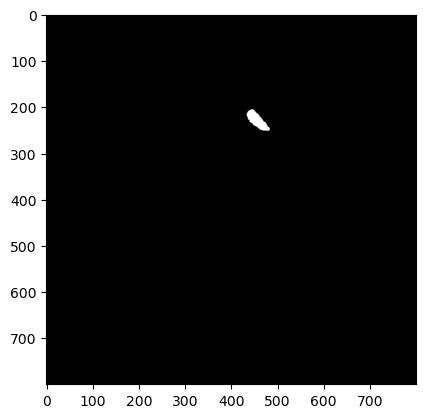

In [25]:
q = masks.cpu().float().numpy()
plt.imshow(q[1], cmap="gray")

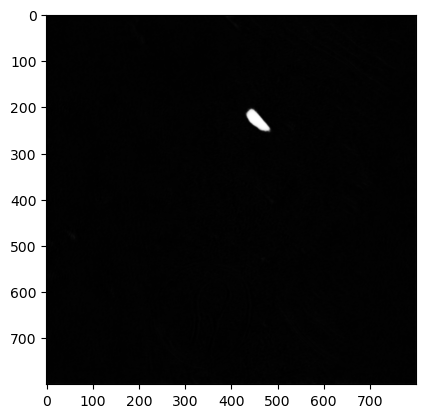

In [27]:
import matplotlib.pyplot as plt 

out1 = out[1]
plt.imshow(out1, cmap="gray")

In [1]:
import pytorch_lightning as L 
import modules
import json
import utils
import torch
import importlib 
import Unet
importlib.reload(Unet)
# trainer = L.Trainer(devices=[0], max_epochs=30) 

/home/feity/anaconda3/envs/pytorch/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'Unet' from '/home/feity/cryoem/Unet.py'>

In [2]:
import os
path = "/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr/train_mask"
with open(os.path.join(path, "config.json"), "r") as f:
    configs = json.load(f)
configs["training"]["train_batch_size"] = 6 
ds = utils.get_stageMask_dataset(configs)

/home/feity/cryoem/utils.py:1169: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(i)


In [3]:
train_dl = ds.train_dataloader()

In [4]:
res = {}

In [12]:
# model = Unet.UNet6(c_in=1, embed_dim=256).cuda(1)
importlib.reload(Unet)
# model = Unet.Easynet().cuda(1)
# model = Unet.UNet6(c_in=1, embed_dim=256, sigmoid=False).cuda(1)
model = modules.UNet6(c_in=1, embed_dim=256, sigmoid=False).cuda(1)
opt = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3) 
cri = torch.nn.BCELoss() 


In [13]:
name = "Unet6 + embed + modules"
res[name] = []
for i in range(3):
    for j, batch in enumerate(train_dl):
        imgs, embed, mask = batch 
        embed = embed.cuda(1)
        mask = mask.cuda(1)
        mask = mask.view(-1, 1, 800, 800)
        opt.zero_grad()
        # print(embed.shape, mask.shape)
        out = model(mask.float().detach(), embed.detach())
        # loss = nn.functional.binary_cross_entropy_with_logits(out, masks.float().detach())
        loss = Unet.sigmoid_focal_loss(out, mask.float().detach().squeeze(1), 6, alpha=0.75)
        loss.backward()
        opt.step()
        if j % 40 == 0:
            print(i, j, loss.item())
            res[name].append(loss.item())

0 0 8.379629135131836
0 40 0.07126224040985107
0 80 0.025017336010932922
0 120 0.02347942255437374
0 160 0.009637094102799892
0 200 0.0068742260336875916
0 240 0.010397667996585369
0 280 0.3363424241542816
0 320 0.004456301685422659
0 360 0.06059598922729492
0 400 0.31176620721817017
0 440 0.06415824592113495
0 480 0.0025154887698590755
0 520 0.007830611430108547
0 560 0.023744886741042137
1 0 0.009058485738933086
1 40 0.0014016597997397184
1 80 0.005616642069071531
1 120 0.010832722298800945
1 160 0.02845095843076706
1 200 0.0035973279736936092
1 240 0.00036614443524740636
1 280 0.0008734468137845397
1 320 0.00027555206906981766
1 360 0.015491155907511711
1 400 0.0002586331684142351
1 440 0.0010790564119815826
1 480 0.0009222512599080801
1 520 0.0010041336063295603
1 560 8.27609546831809e-05
2 0 0.003123300150036812
2 40 0.00047828536480665207
2 80 0.004221824929118156
2 120 0.00038867583498358727
2 160 0.000162365788128227
2 200 0.0005333590088412166
2 240 0.006774788722395897
2 280 

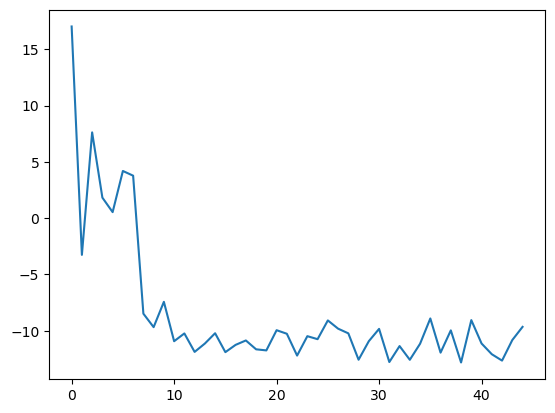

In [10]:
import matplotlib.pyplot as plt
import numpy as np 
a = np.array(res[name])
plt.plot(np.log(a)*3)